# Photometric IGM Tomography

This notebook demonstrates the photometric intergalactic medium (IGM) tomography
technique implemented in `toolslyman`, following

> Giri, Kakiichi, Bianco & Meerburg (2025), *Mapping neutral islands during end
> stages of reionization with photometric intergalactic medium tomography*,
> [arXiv:2505.06350](https://arxiv.org/abs/2505.06350).

During the late stages of reionization, residual patches of neutral hydrogen
("neutral islands") leave a strong imprint on the Lyman-$\alpha$ forest transmission
of background galaxies. Photometric IGM tomography reconstructs a 2D map of this
transmission from deep narrow-band (NB) photometry of many background galaxies,
without requiring spectroscopy of each one.

We will go through the full pipeline on a small toy field:

1. Build a toy field of neutral islands in an otherwise ionized IGM.
2. Model the Lyman-$\alpha$ forest transmission through it (the fluctuating
   Gunn-Peterson approximation, FGPA).
3. Mock-observe it with a narrow-band filter: sample background galaxies, add
   photometric noise, and reconstruct a 2D tomographic map.
4. Compare the reconstructed map to the truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import toolslyman as tl

np.random.seed(42)

## 1. A toy field of neutral islands

Photometric IGM tomography is designed to detect large ($\gtrsim 10\,{\rm cMpc}$)
residual neutral patches during the late stages of reionization (Sec. 1 of the
paper). Instead of a full radiative-transfer simulation, we build a quick toy
field with `toolslyman.toy_model.RandomSphereModel`: random spherical *ionized*
bubbles are grown until a target mean neutral fraction is reached, similar to
the toy models used elsewhere in `toolslyman`'s examples.

This step paints spheres on a $64^3$ grid and takes about a minute to run.

In [2]:
n_grid = 64
box_len = 100.0  # cMpc/h

model = tl.toy_model.RandomSphereModel(n_grid=n_grid, box_len=box_len)
model.set_uniform_bsd(logR_min=0.5, logR_max=1.6)  # ionized bubble radii ~1.6-5 cMpc
model.set_ionization_history(zs=np.array([5.7]), xHI=np.array([0.15]))

xfrac_cubes = model.run(n_batch=20)
island_mask = xfrac_cubes[5.7] < 0.5  # cells belonging to a neutral island
print(f'Neutral island volume filling fraction: {island_mask.mean():.2f}')

Source positions on (64,64,64) grid will be drawn randomly.
Bubble sizes will be drawn randomly from a uniform distribution with minimum and maximum sizes of log(R/Mpc)=0.500 (R=1.649 Mpc) and 1.600 (R=4.953 Mpc), respectively.
1/1 | z=5.700, xhi=0.150


Filling box: 31457280 voxels [00:47, 667317.08 voxels/s]    

Final box mean: 0.851
Neutral island volume filling fraction: 0.15


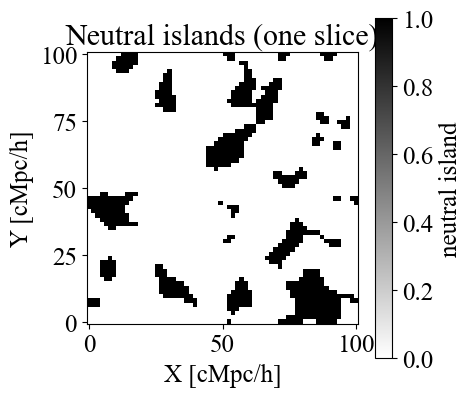

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.5))
grid_1d = np.linspace(0, box_len, n_grid)
im = ax.pcolormesh(grid_1d, grid_1d, island_mask[:, :, n_grid // 2].T,
                    cmap='gray_r', shading='auto')
ax.set_xlabel('X [cMpc/h]')
ax.set_ylabel('Y [cMpc/h]')
ax.set_title('Neutral islands (one slice)')
ax.set_aspect('equal')
fig.colorbar(im, label='neutral island')
plt.tight_layout()
plt.show()

## 2. Lyman-$\alpha$ forest transmission (FGPA)

The Lyman-$\alpha$ forest optical depth of each cell is modelled with the
fluctuating Gunn-Peterson approximation (FGPA; Eq. 1 of the paper, following
Choudhury, Paranjape & Bosman 2021):

$$\tau_i(z) = \kappa_{\rm res}\,\frac{\pi q_e^2}{m_e c}\,f_\alpha\lambda_\alpha\,\frac{(1+z)^3}{H(z)}\,n_{{\rm HI},i}\,,$$

implemented as `tl.tau_nu_lyA_FGPA`. We assign a small residual neutral fraction
to the ionized IGM and a somewhat larger one inside the neutral islands (both
values are still $\ll 1$ -- islands are *mostly*, not fully, neutral even during
the tail end of reionization; we keep the overdensity field uniform here for
simplicity).

The *effective* optical depth (Eq. 3) that is actually observed is a line-of-sight
average over the narrow-band filter width,
$\tau_{\rm eff} = -\ln\left[\frac{1}{N}\sum_i e^{-\tau_i}\right]$, computed here
by `tl.tau_nu_lyA_los` (`method='FGPA'`) over a filter width of $\sim 20\,{\rm cMpc}$,
comparable to the $\sim 42\,{\rm cMpc}$ NB816 filter width used in the paper (Eq. 2).

In [4]:
z = 5.7
xHI_ionized = 1e-5   # residual neutral fraction in the ionized IGM
xHI_island = 5e-4    # residual neutral fraction inside a neutral island

xHI_field = np.where(island_mask, xHI_island, xHI_ionized)
dn_field = np.zeros_like(xHI_field)  # uniform density, for simplicity

tau_eff_cube = tl.tau_nu_lyA_los(z, xHI_field, dn_field, los_len=20*u.Mpc,
                                  box_len=box_len*u.Mpc, method='FGPA', k_res=0.16)
tau_eff = tau_eff_cube[:, :, 0]  # one 2D slice: the true (noiseless) IGM transmission map
print(f'tau_eff range: {tau_eff.min():.2f} - {tau_eff.max():.2f}')

Assuming Planck18 cosmology


100%|██████████| 64/64 [00:00<00:00, 30161.29it/s]

tau_eff range: 0.58 - 29.03


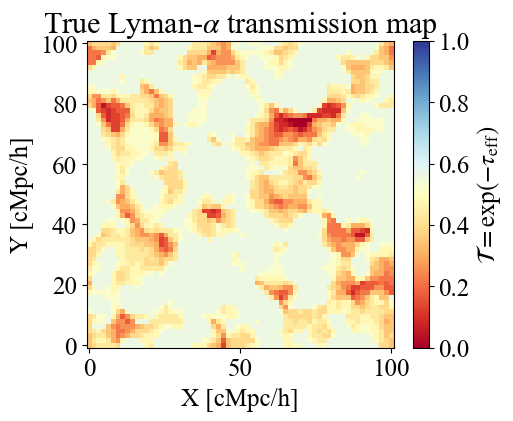

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.pcolormesh(np.linspace(0, box_len, n_grid), np.linspace(0, box_len, n_grid),
                    np.exp(-tau_eff).T, cmap='RdYlBu', vmin=0, vmax=1, shading='auto')
ax.set_xlabel('X [cMpc/h]')
ax.set_ylabel('Y [cMpc/h]')
ax.set_title('True Lyman-$\\alpha$ transmission map')
ax.set_aspect('equal')
fig.colorbar(im, label=r'$\mathcal{T}=\exp(-\tau_{\rm eff})$')
plt.tight_layout()
plt.show()

## 3. Mock photometric IGM tomography

We now mock-observe this field the way a real survey would (Sec. 3 of the
paper): background galaxies are drawn from a UV luminosity function, given a
narrow-band flux measurement with photometric noise, and the transmission map
is reconstructed from these sparse, noisy sightlines with a Gaussian-kernel
interpolation.

`tl.telescope_filters.IGM_tomography_parameters` sets up the observational
configuration for a given narrow-band filter (here Subaru/HSC NB816, as used in
the paper): the background redshift range (Eq. 2), the background galaxy
surface density and expected number in the field of view (Eq. 6), and the
tomographic resolution / Gaussian smoothing length (Eq. 8),
$l_s = \Sigma_{\rm bkg}^{-1/2}$.

In [6]:
igm_tomo_params = tl.telescope_filters.IGM_tomography_parameters(box_len, filter_name='NB816')
igm_tomo_params

### Set IGM tomography parameters with NB816 ###
HSC FoV [deg2] =  1.76 deg2
FoV = 1.76 deg2
Galaxy surface density =  0.006774543270771487 1 / Mpc2  [1/cMpc2]
Galaxy surface density =  151.32711446539494 1 / deg2  [1/deg2]
Galaxy count =  266.3357214590951
transverse resolution/smoothing length = 8.22 [cMpc/h]


{'zmin': 5.81,
 'zmax': 6.86,
 'mNB_lim': <Quantity 28.69280314 mag>,
 'muv_lim': <Quantity 26. mag>,
 'smoothing_length': np.float64(8.220381683969379),
 'Ngal_in_box': 147,
 'R_FoV': np.float64(73.29705159486333)}

`tl.IGM_tomographic_map_reconstruction` runs the rest of the pipeline end to end
for us: it samples background galaxies at random sightlines through the box,
draws their apparent UV magnitudes from the Bouwens et al. (2021) luminosity
function (Eq. 6), adds narrow-band photometric noise (Eqs. 4-5), and reconstructs
the 2D tomographic map with the Gaussian-kernel interpolation of Eq. 7,

$$\mathcal{T}(\mathbf{r}) = \frac{\sum_{i=1}^{N} \mathcal{T}_i K_{l_s}(\mathbf{r}-\mathbf{r}_i)}{\sum_{i=1}^{N} K_{l_s}(\mathbf{r}-\mathbf{r}_i)}\,.$$

In [7]:
tomo = tl.IGM_tomographic_map_reconstruction(
    box_len, n_grid, tau_eff, filter_name='NB816', verbose=False)

print(f"Number of background galaxies in the field: {tomo['x_sample'].size}")
print(f"Tomographic (Gaussian smoothing) resolution: {tomo['IGM_tomography_params']['smoothing_length']:.2f} cMpc/h")

### Set IGM tomography parameters with NB816 ###
HSC FoV [deg2] =  1.76 deg2
FoV = 1.76 deg2
Galaxy surface density =  0.006774543270771487 1 / Mpc2  [1/cMpc2]
Galaxy surface density =  151.32711446539494 1 / deg2  [1/deg2]
Galaxy count =  266.3357214590951
transverse resolution/smoothing length = 8.22 [cMpc/h]


100%|██████████| 147/147 [00:00<00:00, 25622.85it/s]

Number of background galaxies in the field: 147
Tomographic (Gaussian smoothing) resolution: 8.22 cMpc/h


## 4. Truth vs. reconstructed map

`tl.Plot_PhotometricIGM` provides ready-made plots (in the same style as Fig. 1
and Fig. 3 of the paper) that work directly off the dictionary returned by
`IGM_tomographic_map_reconstruction`.

#### Plot: sightline map #####


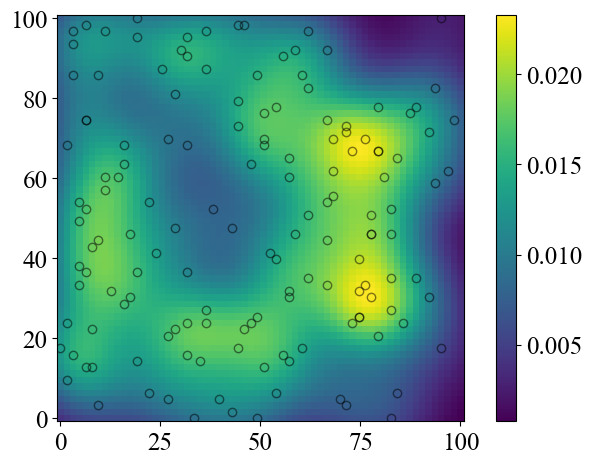

In [8]:
plotter = tl.Plot_PhotometricIGM(tomo_map_reconst=tomo)
plotter.sightline_map()

#### Plot: Simulated IGM map (Truth) #####


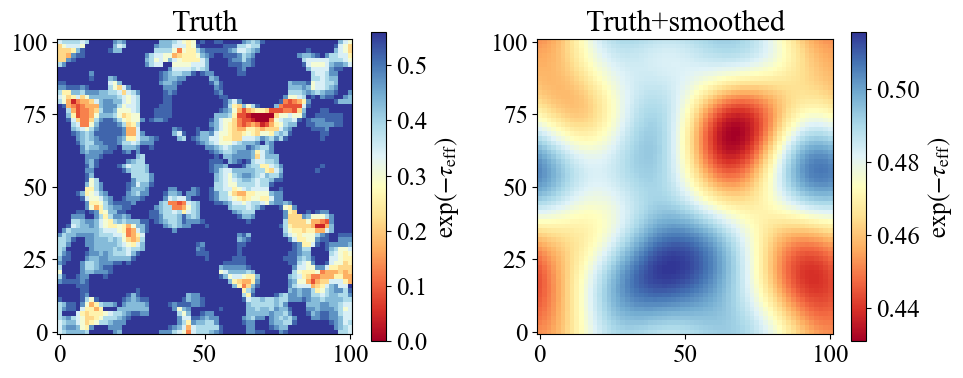

In [9]:
plotter.true_Tigm_map()

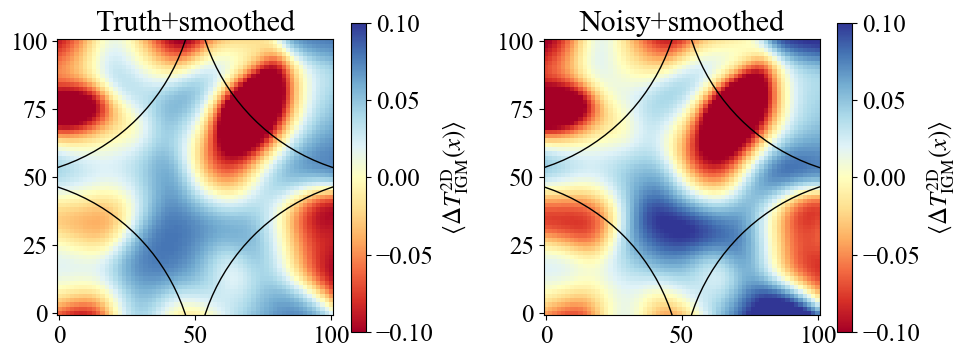

In [10]:
plotter.reconstructed_Tigm_map()

The left panel is the Gaussian-smoothed reconstruction from the (noiseless)
true transmission along each background sightline; the right panel adds
realistic photometric noise. The black circles mark the field of view of
one HSC pointing, tiled to cover the box. Both panels recover the same large
neutral island (red, low transmission) despite the noise -- this is the
signature photometric IGM tomography is designed to detect.

As in Fig. 3 of the paper, we can quantify the fidelity of the reconstruction
with the Spearman rank correlation between the true and reconstructed maps:

In [11]:
from scipy.stats import spearmanr

truth_smoothed = np.exp(-tau_eff)  # same resolution/grid as the reconstruction
rho_noiseless, _ = spearmanr(truth_smoothed.ravel(), tomo['reconst_map'].ravel())
rho_noisy, _ = spearmanr(truth_smoothed.ravel(), tomo['noisy_reconst_map'].ravel())
print(f'Spearman correlation (noiseless reconstruction): {rho_noiseless:.2f}')
print(f'Spearman correlation (with photometric noise):   {rho_noisy:.2f}')

Spearman correlation (noiseless reconstruction): 0.44
Spearman correlation (with photometric noise):   0.40


With only ~150 background galaxies in this small toy field, the correlation is
modest but clearly positive -- consistent with Fig. 3 of the paper, where a
similar number of background sources over a much larger, more realistic field
gives a comparable Spearman coefficient. Increasing the background galaxy
density (a deeper `muv_lim`, or a larger survey area) improves the correlation,
at the cost of requiring fainter, harder-to-confirm background galaxies (Sec. 3.2
of the paper).

**Going further:** the paper also describes a superpixel-based pattern
recognition method (Sec. 3.3) to segment the reconstructed, noisy map into
discrete neutral islands and recover their size distribution. That step is not
yet implemented in `toolslyman` -- see [issue
tracker](https://github.com/sambit-giri/toolslyman/issues) if you would like to
contribute it.